# Introduction to Probability and Statistics

In this notebook, we will play around with some of the concepts we have previously discussed. Many concepts from probability and statistics are well-represented in major libraries for data processing in Python, such as `numpy` and `pandas`.

In [155]:
import numpy as np
import pandas as pd
from random import randint
import matplotlib.pyplot as plt

## Random Variables and Distributions

Let's start with drawing a sample of 30 values from a **uniform distribution** from 0 to 9. We will also compute mean and variance.

In [156]:
# A list of 30 random integers in the range [0, 10]-including both endpoints
sample = [randint(0, 9) for _ in range(30)]
print(f"Sample: {sample}")
print(f"Mean =\t\t{np.mean(sample)}")
print(f"Variance =\t{np.var(sample)}")

Sample: [0, 6, 7, 0, 6, 4, 7, 0, 5, 2, 6, 1, 0, 4, 9, 5, 9, 6, 7, 8, 5, 7, 1, 9, 7, 7, 4, 9, 9, 6]
Mean =		5.2
Variance =	8.693333333333333


To visually estimate how many different values are there in the sample, we can plot the **histogram**:

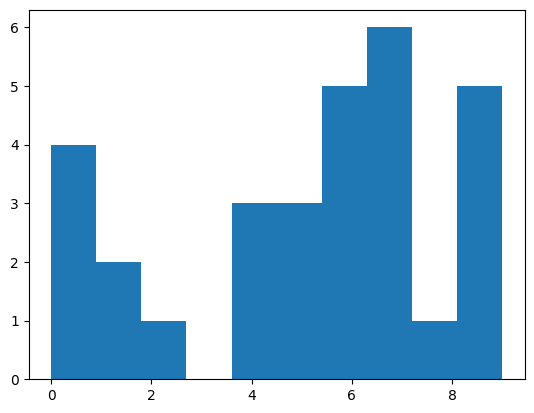

In [157]:
plt.hist(sample)
plt.show()

## Analyzing Real Data

Mean and variance are vey important when analyzing real-world data. Let's load the data about baseball players from [SOCR MLB Height/Weight Data](http://wiki.stat.ucla.edu/socr/index.php/SOCR_Data_MLB_HeightsWeights).

In [158]:
df = pd.read_csv(
    "../../data/SOCR_MLB.tsv",
    header=None,
    sep="\t",
    names=["Name", "Team", "Role", "Weight", "Height", "Age"],
)
df

,Name,Team,Role,Weight,Height,Age
0,Adam_Donachie,BAL,Catcher,74,180.0,22.99
1,Paul_Bako,BAL,Catcher,74,215.0,34.69
2,Ramon_Hernandez,BAL,Catcher,72,210.0,30.78
3,Kevin_Millar,BAL,First_Baseman,72,210.0,35.43
4,Chris_Gomez,BAL,First_Baseman,73,188.0,35.71
...,...,...,...,...,...,...
1029,Brad_Thompson,STL,Relief_Pitcher,73,190.0,25.08
1030,Tyler_Johnson,STL,Relief_Pitcher,74,180.0,25.73
1031,Chris_Narveson,STL,Relief_Pitcher,75,205.0,25.19
1032,Randy_Keisler,STL,Relief_Pitcher,75,190.0,31.01


> We are using a package called [**Pandas**](https://pandas.pydata.org) here for data analysis. We will talk more about Pandas and working with data in Python later in this course.

Let's compute average values for age, height and weight:

In [159]:
df[["Age", "Height", "Weight"]].mean(axis=0)

Age        28.736712
Height    201.689255
Weight     73.697292
dtype: float64

Now let's focus on height, and compute standard deviation and variance:

In [160]:
print(list(df["Height"])[:20])

[180.0, 215.0, 210.0, 210.0, 188.0, 176.0, 209.0, 200.0, 231.0, 180.0, 188.0, 180.0, 185.0, 160.0, 180.0, 185.0, 197.0, 189.0, 185.0, 219.0]


In [161]:
mean = df["Height"].mean()
var = df["Height"].var()
std = df["Height"].std()

print(f"Mean\t\t\t{mean}\nVariance\t\t{var}\nStandard Deviation\t{std}")

Mean			201.6892545982575
Variance		440.64268481205494
Standard Deviation	20.99149077154967


In addition to mean, it makes sense to look at the median values and quartiles. They can be visualized using a **box plot**:

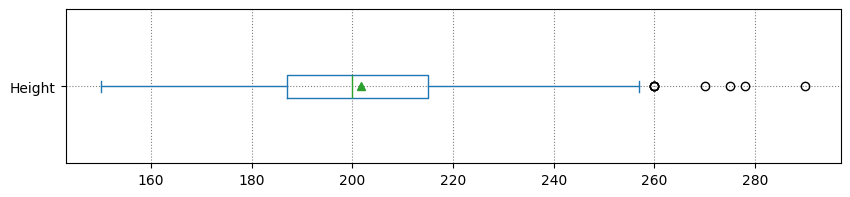

In [162]:
# plt.figure(figsize=(10, 2))
# plt.boxplot(df["Height"], vert=False, showmeans=True)
# plt.grid(color="gray", linestyle="dotted")
# plt.tight_layout()
# plt.show()

df["Height"].plot.box(
    vert=False,
    showmeans=True,
    figsize=(10, 2),
    layout="tight",
)
plt.grid(color="gray", linestyle="dotted")

plt.show()

We can also make boxplots of subsets of our dataset, for example, grouped by player role

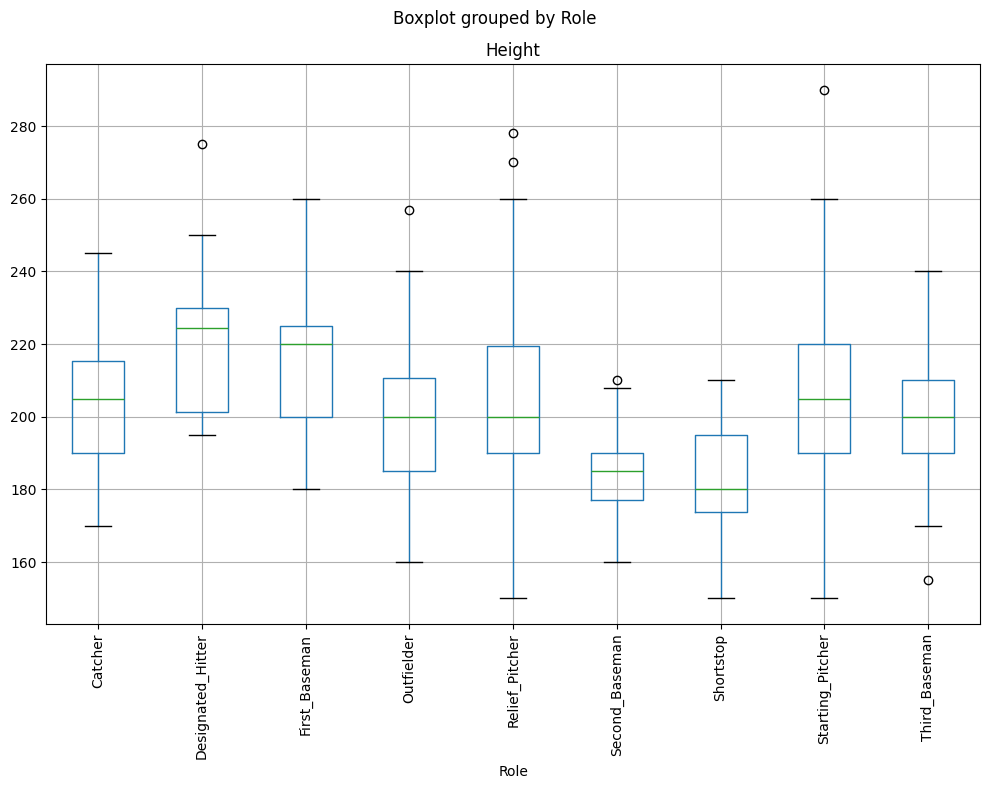

In [163]:
df.boxplot(column="Height", by="Role", figsize=(10, 8))
plt.xticks(rotation="vertical")
plt.tight_layout()

plt.show()

> **Note:** This diagram suggests, that on average, the heights of first basement are higher than heights of second basemen. Later we will learn how we can test this hypothesis more formally, and how to demonstrate that our data is statistically significant to show that.

Age, height and weight are all continuous random variables. What do you think their distribution is?<br/>
A good way to find out is to plot the histogram of values.

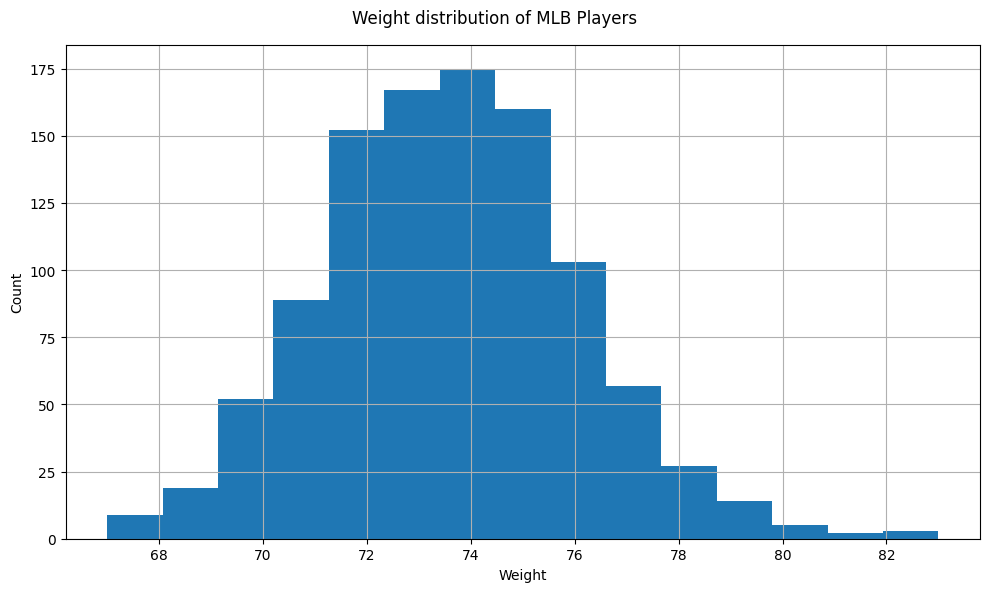

In [164]:
df["Weight"].hist(bins=15, figsize=(10, 6))
plt.suptitle("Weight distribution of MLB Players")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.tight_layout()

plt.show()

## Normal Distribution

Let's create an artificial sample of heights that follows a normal distribution with the same mean and std as our real data:

In [165]:
generated = np.random.normal(mean, std, 1000)
generated[:20]

array([211.39846318, 214.67165205, 204.25659222, 213.59275146,
       214.87720387, 208.0784456 , 233.62903035, 211.81224811,
       239.12616844, 201.9907982 , 231.48782821, 206.10459135,
       201.54103626, 194.18333764, 184.77636707, 190.29694753,
       193.09260134, 205.53807874, 178.24518346, 216.78332751])

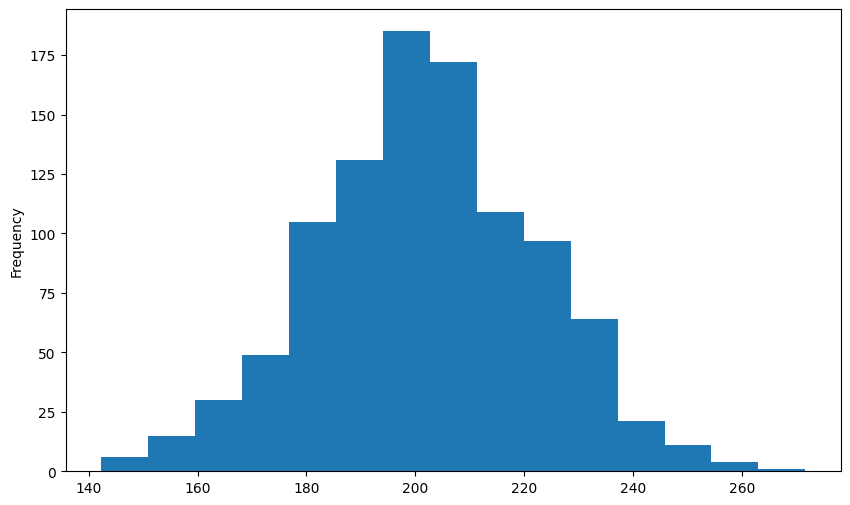

In [166]:
generated = pd.Series(generated)
generated.plot.hist(bins=15, figsize=(10, 6), layout="tight")
plt.show()

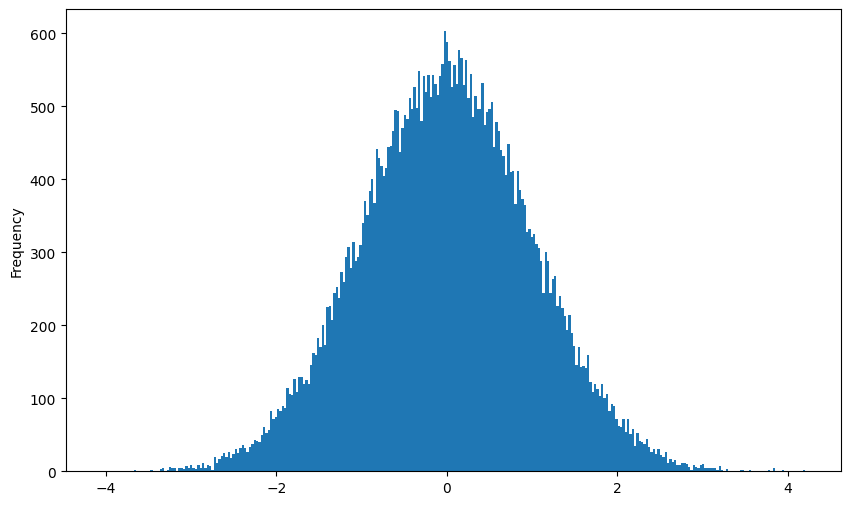

In [167]:
# A normal distribution
my_sample = pd.Series(np.random.normal(0, 1, 50_000))
my_sample.plot.hist(bins=300, layout="tight", figsize=(10, 6))
plt.show()

Since most values in real life are normally distributed, we should not use a uniform random number generator to generate sample data. Here is what happens if we try to generate heights with a uniform distribution (generated by np.random.rand):

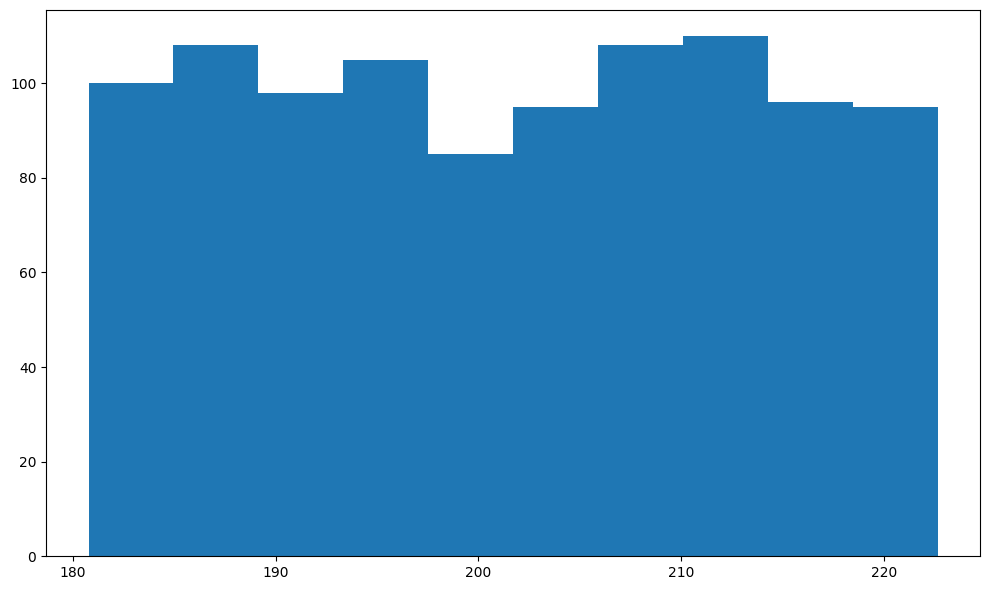

In [168]:
wrong_sample = np.random.rand(1000) * 2 * std + mean - std
plt.figure(figsize=(10, 6))
plt.hist(wrong_sample)
plt.tight_layout()
plt.show()

## Confidence Intervals

Let's now calculate confidence intervals for the weights and heights of baseball players. We will use the code [from this stackoverflow discussion](https://stackoverflow.com/questions/15033511/compute-a-confidence-interval-from-sample-data):

In [169]:
import scipy.stats as stats


def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)  # sample size
    df = n - 1  # degrees of freedom
    alpha = 1 - confidence  # the remaining probability; must be split into two, for each tail of the distribution
    m, standard_error = np.mean(a), stats.sem(a)
    critical_t_ = stats.t.ppf(1 - alpha / 2, df)
    h = critical_t_ * standard_error
    return m, h


for p in [0.85, 0.90, 0.95]:
    m, h = mean_confidence_interval(df["Weight"].fillna(0), p)
    print(f"p = {p:.2f}, mean = {m:.2f} ± {h:.2f}")

p = 0.85, mean = 73.70 ± 0.10
p = 0.90, mean = 73.70 ± 0.12
p = 0.95, mean = 73.70 ± 0.14


## Hypothesis Testing

Let's explore different roles in our baseball players dataset:

In [170]:
df.groupby("Role").agg({"Weight": "mean", "Height": "mean", "Age": "count"})

,Weight,Height,Age
Role,,,
Catcher,72.723684,204.328947,76
Designated_Hitter,74.222222,220.888889,18
First_Baseman,74.000000,213.109091,55
Outfielder,73.010309,199.113402,194
Relief_Pitcher,74.374603,203.517460,315
Second_Baseman,71.362069,184.344828,58
Shortstop,71.903846,182.923077,52
Starting_Pitcher,74.719457,205.163636,221
Third_Baseman,73.044444,200.955556,45


From the above table data we see that First_Baseman have average height of **213.11** while Second_Baseman have average height of **184.34**.<br/> 
We might think that First Basemen are taller than Second Basemen but this is only a hypothesis.<br/>
Let's test this hypothesis. The simplest way to do this is to test the confidence intervals.

In [171]:
for p in [0.85, 0.90, 0.95]:
    m1, h1 = mean_confidence_interval(df.loc[df["Role"] == "First_Baseman", ["Height"]], p)
    m2, h2 = mean_confidence_interval(df.loc[df["Role"] == "Second_Baseman", ["Height"]], p)
    print(f"Conf = {p:.2f}, 1st baseman height: {m1-h1[0]:.2f} - {m1+h1[0]:.2f}", end="")
    print(f", 2nd baseman height: {m2-h2[0]:.2f} - {m2+h2[0]:.2f}", end="\n")

Conf = 0.85, 1st baseman height: 209.36 - 216.86, 2nd baseman height: 182.24 - 186.45
Conf = 0.90, 1st baseman height: 208.82 - 217.40, 2nd baseman height: 181.93 - 186.76
Conf = 0.95, 1st baseman height: 207.97 - 218.25, 2nd baseman height: 181.45 - 187.24


We can see that the intervals <u>do not overlap</u>

A statistically more correct way to prove the hypothesis, is to use a **Student t-test**.

In [172]:
from scipy.stats import ttest_ind

# This tests the null hypothesis that: two independent samples have identical averages.
tval, pval = ttest_ind(
    df.loc[df["Role"] == "First_Baseman", ["Height"]],
    df.loc[df["Role"] == "Second_Baseman", ["Height"]],
    equal_var=False,  # perform a t-test which does not assume the two sample variances are equal
)

print(f"t-value = {tval[0]:.2f}\np-value = {pval[0]:.2f}")

t-value = 9.77
p-value = 0.00


The two values returned by the `ttest_ind` function are:

- **p-value** can be considered as the probability of two distributions having the same mean. In our case, it is very low, meaning that there is strong evidence supporting that First Basemen are taller.
- **t-value** is the indermediate value of normalized mean difference that is used in the t-test, and is compared against a threshold value for a given confidence level.

## Simulating a Normal Distribution with the Central Limit Theorem

The pseudo-random generator in Python is designed to give us a uniform distribution. If we want to create a generator for normal distribution, we can use the Central Limit Theorem. To get a normally distributed value, we will just compute a mean of a uniform-generated sample.

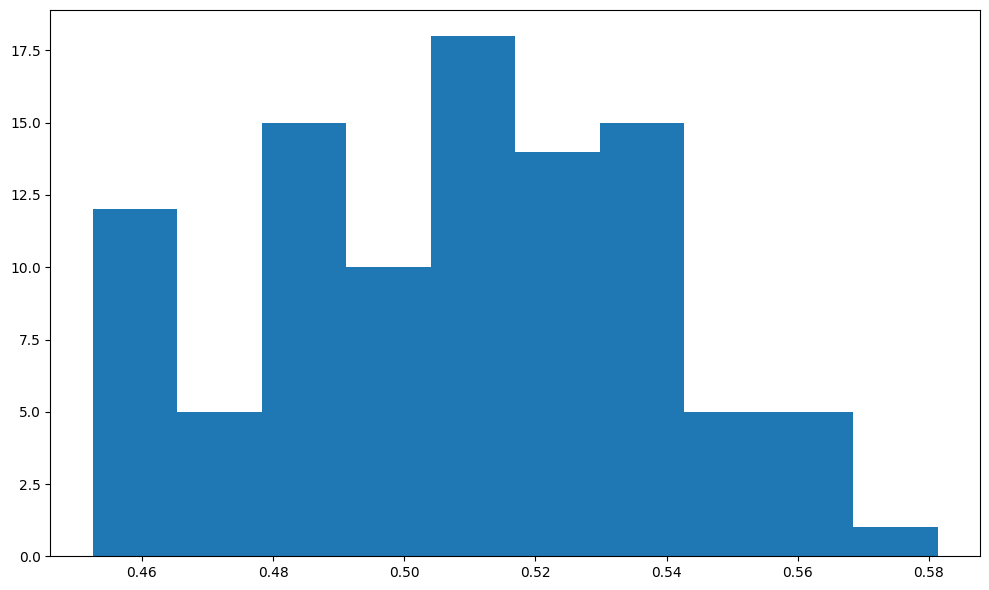

In [173]:
import random


def normal_random(sample_size=100):
    sample = [random.uniform(0, 1) for _ in range(sample_size)]
    return sum(sample) / sample_size


sample = [normal_random() for _ in range(100)]
plt.figure(figsize=(10, 6))
plt.hist(sample)
plt.tight_layout()
plt.show()

## Correlation and Evil Baseball Corp

Correlation allows us to find relations between data sequences. In our toy example, let's pretend there is an evil baseball corporation that pays its players according to their height - the taller the player is, the more money he gets. Suppose there is a base sallary of $1000, and an additional bonus from $0 to $100, depending on height. We will take the real players from MLB, and compute their imaginary salaries:

In [174]:
heights = df["Height"]
salaries = 100 + (heights - heights.min()) / (heights.max() - heights.mean()) * 1000
print(list(zip(heights, salaries))[:10])

[(180.0, 439.70950945464506), (215.0, 836.0372704850643), (210.0, 779.4190189092901), (210.0, 779.4190189092901), (188.0, 530.2987119758837), (176.0, 394.4149081940257), (209.0, 768.0953685941353), (200.0, 666.1825157577418), (231.0, 1017.2156755275416), (180.0, 439.70950945464506)]


Let's now compute covariance and correlation of those sequences. `np.cov` will give us a so-called **covariance matrix**, which is an extension of covariance to multiple variables. The element $M_{ij}$ of the covariance matrix $M$ is a correlation between input variables $X_i$ and $X_j$, and diagonal values $M_{ii}$ is the variance of $X_i$. Similarly, `np.corrcoef` will give us the **correlation matrix**.

In [175]:
print(f"Covariance matrix:\n{np.cov(heights,salaries)}")
print(f"Covariance = {np.cov(heights,salaries)[0,1]}")
print(f"Correlation = {np.corrcoef(heights,salaries)[0,1]}")

Covariance matrix:
[[nan nan]
 [nan nan]]
Covariance = nan
Correlation = nan


A correlation equal to 1 means that there is a **strong relation** between two variables. We can visually see the linear relation by plotting one value against the other:

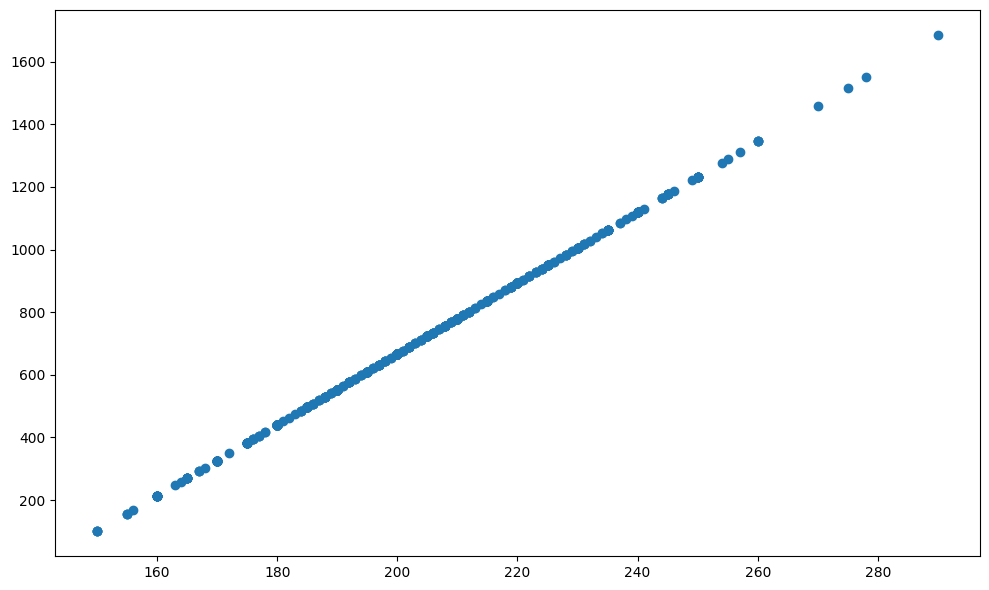

In [176]:
fig, ax = plt.subplots(figsize=(10, 6), layout="tight")
ax.scatter(heights, salaries)
plt.show()

Let's see what happens if the relationship is not linear. Suppose that our corporation decided to hide the obvious linear dependency between heights and salaries, and introduced some non-linearity into the formula, such as `sin`.

In [177]:
salaries = 1000 + np.sin((heights - heights.min()) / (heights.max() - heights.mean())) * 100
print(f"Correlation = {np.corrcoef(heights,salaries)[0,1]}")

Correlation = nan


In this case the correlation is slightly smaller, but it is still quite high. Now, to make the relation even less obvious, we might want to add some extra randomness by adding some random variable to the salary. Let's see what happens:

In [178]:
salaries = (
    1000
    + np.sin((heights - heights.min()) / (heights.max() - heights.mean())) * 100
    + np.random.random(size=len(heights)) * 20
    - 10
)
print(f"Correlation = {np.corrcoef(heights, salaries)[0,1]}")

Correlation = nan


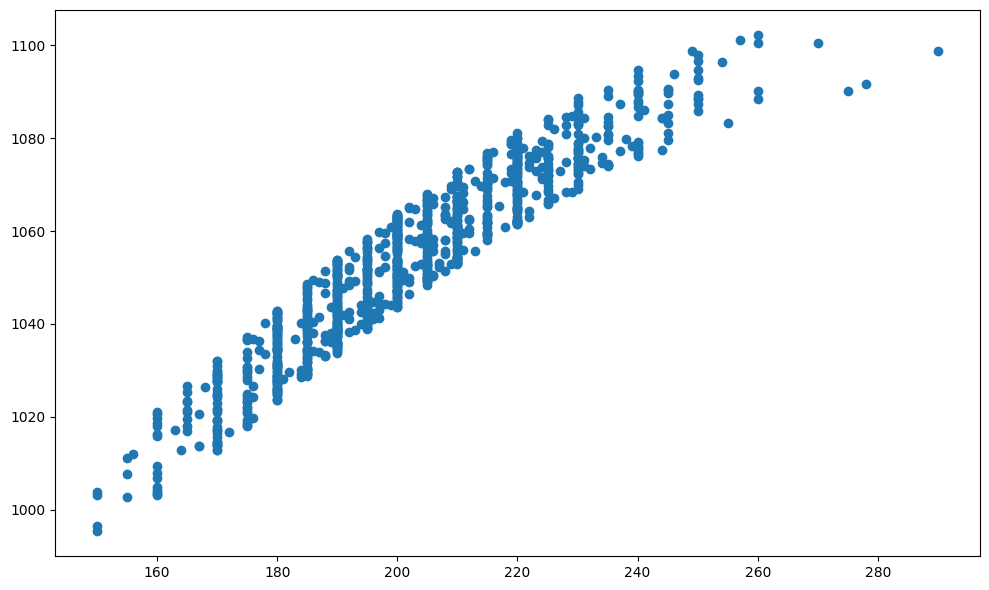

In [179]:
plt.figure(figsize=(10, 6))
plt.scatter(heights, salaries)
plt.tight_layout()
plt.show()

> Can you guess why the dots line up into vertical lines like this?

We have observed the correlation between an artificially engineered concept like salary, and the observed variable *height*. Let's also see it the two observed variables, such as height and weight, correlate too:

In [180]:
np.corrcoef(df["Height"], df["Weight"])

array([[nan, nan],
       [nan,  1.]])

In [183]:
np.corrcoef(df["Height"].bfill(), df["Weight"].bfill())

array([[1.        , 0.53220789],
       [0.53220789, 1.        ]])

There is indeed a correlation, but not such a strong one as in our artificial example. Indeed, if we look at the same scatter plot of one value against the other, the relation would be much less obvious.

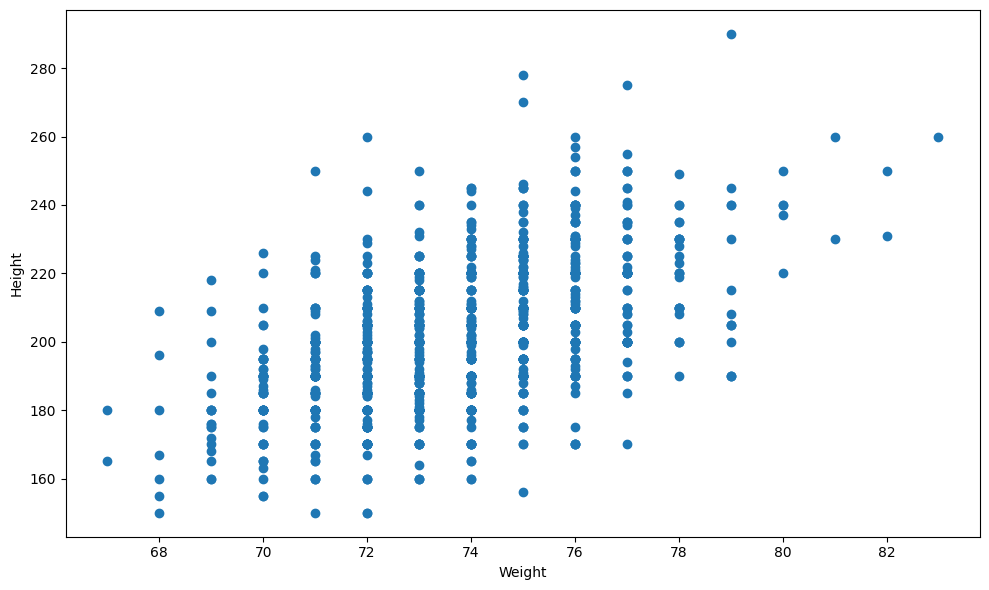

In [184]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Weight"], df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.tight_layout()
plt.show()